# INSAT-3DR Data Visualization
This notebook helps in visualizing the preprocessed INSAT-3DR frames.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

# Load manifest
with open('../data/manifest.json', 'r') as f:
    manifest = json.load(f)

print(f"Total samples: {len(manifest)}")

Total samples: 1463


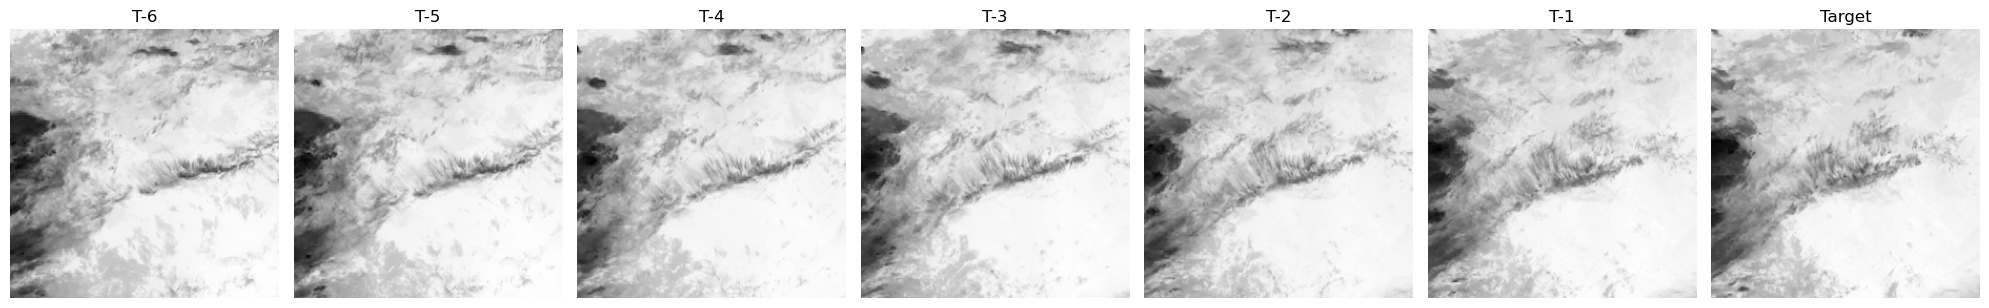

In [2]:
def show_sequence(sample_idx):
    sample = manifest[sample_idx]
    inputs = sample['input_frames']
    target = sample['target_frame']
    
    fig, axes = plt.subplots(1, 7, figsize=(20, 5))
    
    for i, path in enumerate(inputs):
        img = np.load(path)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'T-{6-i}')
        axes[i].axis('off')
        
    target_img = np.load(target)
    axes[6].imshow(target_img, cmap='gray')
    axes[6].set_title('Target')
    axes[6].axis('off')
    
    plt.tight_layout()
    plt.show()

# Show the first sequence
show_sequence(0)

## 4. Inference with `model_epoch_9.pt`
Compare the model prediction from checkpoint `model_epoch_9.pt` with the real target frame.

In [3]:
import sys
import os
import torch
import yaml
from pathlib import Path

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset import Clouds
from src.models.convlstm import ConvLSTM

config = yaml.safe_load(open(project_root / 'config.yaml'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ConvLSTM(
    input_dim=1,
    hidden_dim=config['model']['hidden_dim'],
    kernel_size=config['model']['kernel_size'],
    num_layers=config['model']['num_layers']
).to(device)

checkpoint_path = project_root / 'checkpoints' / 'model_epoch_9.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded {checkpoint_path.name} epoch={checkpoint.get("epoch", "unknown")} on {device}')

Loaded model_epoch_9.pt epoch=9 on cuda


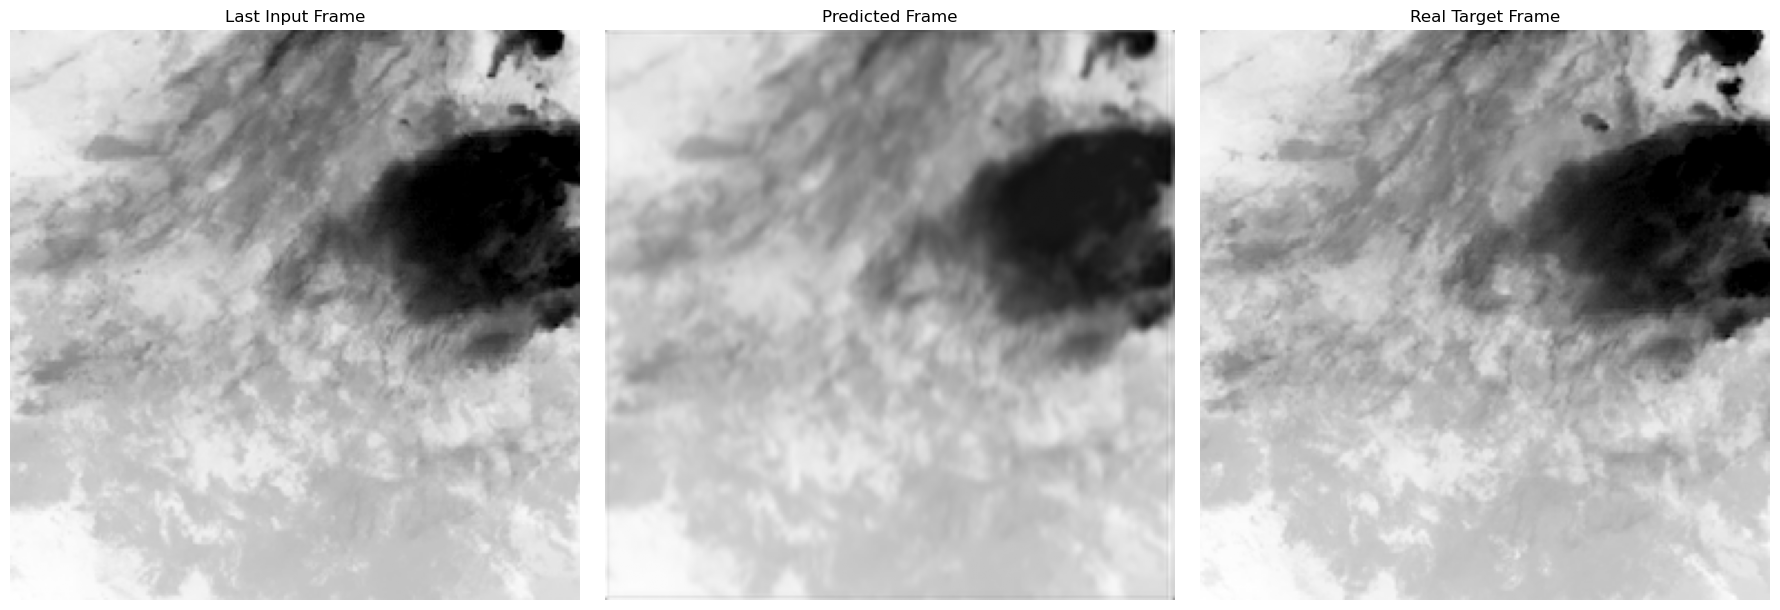

In [5]:
full_dataset = Clouds(manifest_path=str(project_root / 'data' / 'manifest.json'), T=config['data']['T'])
val_start = int(config['data']['train_split'] * len(full_dataset))
sample_idx = val_start
inputs, target = full_dataset[sample_idx]
model_input = inputs.unsqueeze(0).unsqueeze(2).to(device)

with torch.no_grad():
    pred = model(model_input).cpu().squeeze().numpy()

last_input = inputs[-1].numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(last_input, cmap='gray')
axes[0].set_title('Last Input Frame')
axes[0].axis('off')
axes[1].imshow(pred, cmap='gray')
axes[1].set_title('Predicted Frame')
axes[1].axis('off')
axes[2].imshow(target.numpy(), cmap='gray')
axes[2].set_title('Real Target Frame')
axes[2].axis('off')
plt.tight_layout()
plt.show()
